# Exploratory Data Analysis — Multihop Golden Dataset
### Dataset: multihop_goldentruth.jsonl | Sirah Nabawiyah RAG System
---

**Fokus Analisis:** Mengeksplorasi **dataset Q&A** yang telah dihasilkan dari dokumen sumber.

*Catatan: Notebook ini berbeda dengan EDA_Dokumen_Sirah.ipynb. Notebook ini berfokus pada dataset Q&A yang akan digunakan, sedangkan EDA_Dokumen_Sirah.ipynb berfokus pada statistik buku aslinya.*

Notebook ini relevan untuk mendokumentasikan proses **Data Preparation & Splitting** sebelum masuk ke tahap evaluasi maupun fine-tuning.

---

**Tujuan notebook ini:**
- Memahami distribusi dan karakteristik dataset benchmark multihop (distribusi jenis pertanyaan, analisis panjang token)
- Mengidentifikasi potensi masalah atau anomali pada kualitas data
- Memberikan rekomendasi strategi splitting dataset (Train/Val/Test)


In [1]:
import json
import os
import re
from collections import Counter, defaultdict

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── KONFIGURASI ──────────────────────────────────────────────────────
# Ubah path sesuai struktur folder proyek Anda
DATA_FILE = "../../data/finetune_dataset/dataset_final_gabungan.jsonl"
PLOT_DIR  = "../../data/eda_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Ganti False untuk tema terang (untuk cetak/PDF skripsi)
DARK_MODE = False

# ── TEMA ─────────────────────────────────────────────────────────────
if DARK_MODE:
    STYLE = {
        "figure.facecolor": "#1a1a2e", "axes.facecolor": "#16213e",
        "axes.edgecolor": "#e94560",   "axes.labelcolor": "#eaeaea",
        "xtick.color": "#eaeaea",      "ytick.color": "#eaeaea",
        "text.color": "#eaeaea",       "font.size": 11,
        "axes.titlesize": 14,          "axes.labelsize": 12,
        "figure.titlesize": 16,        "legend.facecolor": "#16213e",
        "legend.edgecolor": "#e94560",
    }
    BG_MAIN  = "#1a1a2e"
    BG_AX    = "#16213e"
else:
    STYLE = {
        "figure.facecolor": "#ffffff", "axes.facecolor": "#f8f9fa",
        "axes.edgecolor": "#343a40",   "axes.labelcolor": "#212529",
        "xtick.color": "#495057",      "ytick.color": "#495057",
        "text.color": "#212529",       "font.size": 11,
        "axes.titlesize": 14,          "axes.labelsize": 12,
        "figure.titlesize": 16,        "legend.facecolor": "#ffffff",
        "legend.edgecolor": "#dee2e6",
    }
    BG_MAIN  = "#ffffff"
    BG_AX    = "#f8f9fa"

plt.rcParams.update(STYLE)

PALETTE = ["#e94560", "#0f3460", "#533483", "#16c79a", "#f5a623",
           "#11999e", "#ff6b6b", "#6c5ce7", "#00b894", "#fdcb6e"]

print("✅ Konfigurasi selesai.")
print(f"   Mode: {'Dark (Presentasi)' if DARK_MODE else 'Light (Cetak/PDF)'}")
print(f"   Plot dir: {os.path.abspath(PLOT_DIR)}")


✅ Konfigurasi selesai.
   Mode: Light (Cetak/PDF)
   Plot dir: c:\Users\Awalludin\OneDrive - PT. Telekomunikasi Indonesia\Documents\Aulia\TA NLP\TA_preprocess\TA_sirah\data\eda_plots


In [2]:
def load_data(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return records


def extract_question(user_content: str) -> str:
    """Ekstrak hanya teks pertanyaan dari user message (tanpa konteks chunk)."""
    # Format: "Konteks:\n...\n\nPertanyaan: <teks pertanyaan>"
    if "\nPertanyaan: " in user_content:
        return user_content.split("\nPertanyaan: ")[-1].strip()
    # Fallback: ambil setelah baris kosong terakhir
    parts = user_content.strip().split("\n\n")
    return parts[-1].replace("Pertanyaan: ", "").strip()


def extract_fields(records):
    data = {
        "context_type"     : [],
        "difficulty"       : [],
        "question_type"    : [],
        "bab_titles"       : [],        # flat
        "bab_per_qa"       : [],        # per record
        "judge_score"      : [],
        "num_gold_chunks"  : [],
        "num_source_chunks": [],
        "answer_len_char"  : [],
        "answer_len_word"  : [],
        "question_len_char": [],        # FIXED: hanya teks pertanyaan
        "question_len_word": [],        # ADDED: word count
        "context_len_word" : [],        # ADDED: panjang konteks
        "page_range"       : [],
    }

    for rec in records:
        meta = rec.get("metadata", {})
        msgs = rec.get("messages", [])

        data["context_type"].append(meta.get("context_type", "unknown"))
        data["difficulty"].append(meta.get("difficulty", "unknown"))
        data["question_type"].append(meta.get("type", "unknown"))
        data["judge_score"].append(meta.get("judge_score", 0))
        data["num_gold_chunks"].append(len(meta.get("gold_chunk_ids", [])))
        data["num_source_chunks"].append(meta.get("num_source_chunks", 0))
        data["page_range"].append(meta.get("page_range", ""))

        babs = meta.get("bab_titles", [])
        data["bab_per_qa"].append(babs)
        data["bab_titles"].extend(babs)

        answer, user_content = "", ""
        for msg in msgs:
            if msg["role"] == "assistant":
                answer = msg.get("content", "")
            elif msg["role"] == "user":
                user_content = msg.get("content", "")

        question = extract_question(user_content)

        # Pisahkan konteks dan pertanyaan
        ctx_part = user_content[:user_content.find("\nPertanyaan:")] if "\nPertanyaan:" in user_content else ""

        data["answer_len_char"].append(len(answer))
        data["answer_len_word"].append(len(answer.split()))
        data["question_len_char"].append(len(question))
        data["question_len_word"].append(len(question.split()))
        data["context_len_word"].append(len(ctx_part.split()))

    return data


# ── Jalankan ─────────────────────────────────────────────────────────
records = load_data(DATA_FILE)
data    = extract_fields(records)

print(f"✅ Dataset berhasil dimuat")
print(f"   Total records : {len(records):,}")
print(f"   Fields        : {list(data.keys())}")


✅ Dataset berhasil dimuat
   Total records : 1,868
   Fields        : ['context_type', 'difficulty', 'question_type', 'bab_titles', 'bab_per_qa', 'judge_score', 'num_gold_chunks', 'num_source_chunks', 'answer_len_char', 'answer_len_word', 'question_len_char', 'question_len_word', 'context_len_word', 'page_range']


## 1. Statistik Deskriptif

In [3]:
def print_summary(records, data):
    n = len(records)
    print("=" * 65)
    print("  📊  EDA — MULTIHOP GOLDEN DATASET")
    print("=" * 65)

    print(f"\n  Total QA pairs    : {n:,}")
    print(f"  Unique bab        : {len(set(data['bab_titles']))}")

    sections = [
        ("📂 TIPE KONTEKS",     "context_type"),
        ("🎯 TINGKAT KESULITAN","difficulty"),
        ("❓ TIPE PERTANYAAN",  "question_type"),
    ]
    for title, key in sections:
        print(f"\n  {'─'*48}")
        print(f"  {title}")
        print(f"  {'─'*48}")
        for val, cnt in Counter(data[key]).most_common():
            print(f"    {val:<25s}: {cnt:>5,}  ({cnt*100/n:.1f}%)")

    print(f"\n  {'─'*48}")
    print(f"  ⭐ SKOR JUDGE (LLM-as-a-Judge)")
    print(f"  {'─'*48}")
    scores = data["judge_score"]
    for s in sorted(set(scores)):
        cnt = scores.count(s)
        bar = "█" * int(cnt * 40 / n)
        print(f"    Score {s:<3}: {cnt:>5,}  ({cnt*100/n:>5.1f}%) {bar}")
    print(f"    Mean score  : {np.mean(scores):.3f}  | Std: {np.std(scores):.3f}")

    print(f"\n  {'─'*48}")
    print(f"  🧩 GOLD CHUNKS PER SOAL")
    print(f"  {'─'*48}")
    gc = data["num_gold_chunks"]
    print(f"    Min/Max/Mean/Median: {min(gc)} / {max(gc)} / {np.mean(gc):.2f} / {np.median(gc):.1f}")
    for n_c in sorted(set(gc)):
        cnt = gc.count(n_c)
        print(f"    {n_c} chunks: {cnt:>5,}  ({cnt*100/len(gc):.1f}%)")

    print(f"\n  {'─'*48}")
    print(f"  📝 PANJANG TEKS (FIXED: hanya teks pertanyaan)")
    print(f"  {'─'*48}")
    qw = data["question_len_word"]
    aw = data["answer_len_word"]
    cw = data["context_len_word"]
    print(f"    Pertanyaan (kata) — Min:{min(qw)}  Max:{max(qw)}  Mean:{np.mean(qw):.1f}  Median:{np.median(qw):.1f}")
    print(f"    Jawaban    (kata) — Min:{min(aw)}  Max:{max(aw)}  Mean:{np.mean(aw):.1f}  Median:{np.median(aw):.1f}")
    print(f"    Konteks    (kata) — Min:{min(cw)}  Max:{max(cw)}  Mean:{np.mean(cw):.1f}")

    print(f"\n  {'─'*48}")
    print(f"  📚 TOP 15 BAB")
    print(f"  {'─'*48}")
    bab_ctr = Counter()
    for babs in data["bab_per_qa"]:
        for b in set(babs): bab_ctr[b] += 1
    for bab, cnt in bab_ctr.most_common(15):
        short = bab[:42]+"..." if len(bab)>42 else bab
        print(f"    {short:<45s}: {cnt:>4,}")
    print(f"\n{'='*65}\n")


print_summary(records, data)


  📊  EDA — MULTIHOP GOLDEN DATASET

  Total QA pairs    : 1,868
  Unique bab        : 57

  ────────────────────────────────────────────────
  📂 TIPE KONTEKS
  ────────────────────────────────────────────────
    intra_bab                : 1,727  (92.5%)
    cross_bab                :   141  (7.5%)

  ────────────────────────────────────────────────
  🎯 TINGKAT KESULITAN
  ────────────────────────────────────────────────
    hard                     : 1,368  (73.2%)
    unknown                  :   500  (26.8%)

  ────────────────────────────────────────────────
  ❓ TIPE PERTANYAAN
  ────────────────────────────────────────────────
    synthesis                :   522  (27.9%)
    factual                  :   500  (26.8%)
    causal_chain             :   486  (26.0%)
    timeline                 :   360  (19.3%)

  ────────────────────────────────────────────────
  ⭐ SKOR JUDGE (LLM-as-a-Judge)
  ────────────────────────────────────────────────
    Score 0  :   500  ( 26.8%) ██████████

## 2. Pemeriksaan Kualitas Data
> **Temuan penting yang perlu diperhatikan sebelum training/evaluasi.**

In [4]:
print("=" * 60)
print("  🔍 DATA QUALITY CHECK")
print("=" * 60)

n = len(records)

# 1. Missing values
print("\n  1. Missing / null values per field:")
fields_to_check = ["type", "difficulty", "context_type", "judge_score",
                   "expected_answer", "bab_titles", "gold_chunk_ids"]
for key in fields_to_check:
    missing = sum(1 for r in records if not r["metadata"].get(key))
    status = "✅" if missing == 0 else "⚠️ "
    print(f"    {status} {key:<20s}: {missing:>4} missing")

# 2. Difficulty uniformity — PENTING
diff_counts = Counter(data["difficulty"])
print(f"\n  2. Distribusi difficulty (PERHATIAN):")
for d, cnt in diff_counts.items():
    flag = "⚠️  SEMUA SAMA — plot difficulty tidak informatif!" if cnt == n else "✅"
    print(f"    {d}: {cnt}/{n} ({cnt*100/n:.1f}%)  {flag}")

# 3. UNKNOWN BAB investigation
unknown_records = [r for r in records if "UNKNOWN BAB" in r["metadata"].get("bab_titles", [])]
print(f"\n  3. Record dengan UNKNOWN BAB: {len(unknown_records)} ({len(unknown_records)*100/n:.1f}%)")
if unknown_records:
    types_unknown = Counter(r["metadata"]["type"] for r in unknown_records)
    scores_unknown = Counter(r["metadata"]["judge_score"] for r in unknown_records)
    print(f"     Distribusi type  : {dict(types_unknown)}")
    print(f"     Distribusi score : {dict(scores_unknown)}")
    print(f"     Contoh page_range: {[r['metadata']['page_range'] for r in unknown_records[:5]]}")
    # Sample question
    sample_q = unknown_records[0]["messages"][1]["content"]
    question_only = sample_q.split("\nPertanyaan: ")[-1].strip() if "\nPertanyaan: " in sample_q else ""
    print(f"     Contoh pertanyaan: '{question_only[:120]}...'")

# 4. Duplikat pertanyaan
questions = []
for r in records:
    u = r["messages"][1]["content"]
    q = u.split("\nPertanyaan: ")[-1].strip() if "\nPertanyaan: " in u else u
    questions.append(q.lower().strip())
dup_count = len(questions) - len(set(questions))
print(f"\n  4. Duplikat pertanyaan (exact): {dup_count}")
if dup_count > 0:
    print("     ⚠️  Ada duplikat — pertimbangkan deduplication sebelum splitting")
else:
    print("     ✅ Tidak ada duplikat exact")

# 5. Judge score rendah (<8)
low_score = [(i, r) for i, r in enumerate(records) if r["metadata"].get("judge_score", 10) < 8]
print(f"\n  5. Record dengan judge_score < 8: {len(low_score)}")
if low_score:
    print(f"     ⚠️  Pertimbangkan filter threshold sebelum fine-tuning")

# 6. Short answers (kemungkinan jawaban tidak lengkap)
short_answers = sum(1 for w in data["answer_len_word"] if w <= 3)
print(f"\n  6. Jawaban sangat pendek (≤3 kata): {short_answers} ({short_answers*100/n:.1f}%)")
print("     (Normal untuk tipe factual — nama tokoh, angka, dll)")

print(f"\n{'='*60}")
print("  ✅ Quality check selesai")
print(f"{'='*60}")


  🔍 DATA QUALITY CHECK

  1. Missing / null values per field:
    ✅ type                :    0 missing
    ⚠️  difficulty          :  500 missing
    ✅ context_type        :    0 missing
    ⚠️  judge_score         :  500 missing
    ⚠️  expected_answer     :  500 missing
    ⚠️  bab_titles          :  500 missing
    ✅ gold_chunk_ids      :    0 missing

  2. Distribusi difficulty (PERHATIAN):
    hard: 1368/1868 (73.2%)  ✅
    unknown: 500/1868 (26.8%)  ✅

  3. Record dengan UNKNOWN BAB: 43 (2.3%)
     Distribusi type  : {'synthesis': 17, 'timeline': 13, 'causal_chain': 13}
     Distribusi score : {8: 42, 9: 1}
     Contoh page_range: ['1-33', '1-33', '1-33', '1-33', '1-42']
     Contoh pertanyaan: 'Apa saja langkah-langkah yang diambil Rasulullah sebelum dan selama penaklukan Makkah?...'

  4. Duplikat pertanyaan (exact): 0
     ✅ Tidak ada duplikat exact

  5. Record dengan judge_score < 8: 0

  6. Jawaban sangat pendek (≤3 kata): 285 (15.3%)
     (Normal untuk tipe factual — nama 

## 3. Visualisasi Distribusi Dataset

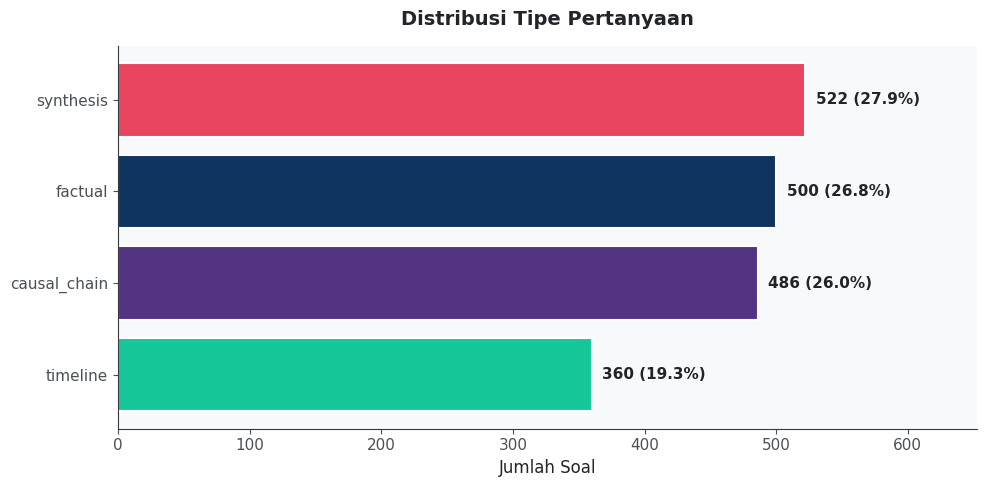

✅ Tersimpan: 01_question_type.png


In [5]:
# ── Plot 1: Tipe Pertanyaan ──────────────────────────────────────────
qt_counts = Counter(data["question_type"])
labels = [k for k, _ in qt_counts.most_common()]
values = [v for _, v in qt_counts.most_common()]
n = len(records)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(labels))]
bars = ax.barh(labels, values, color=colors, edgecolor=BG_MAIN, linewidth=1.5)
for bar, val in zip(bars, values):
    pct = val * 100 / n
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f"{val:,} ({pct:.1f}%)", ha="left", va="center", fontweight="bold", fontsize=11)
ax.set_title("Distribusi Tipe Pertanyaan", fontweight="bold", pad=15)
ax.set_xlabel("Jumlah Soal")
ax.set_xlim(0, max(values) * 1.25)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "01_question_type.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tersimpan: 01_question_type.png")


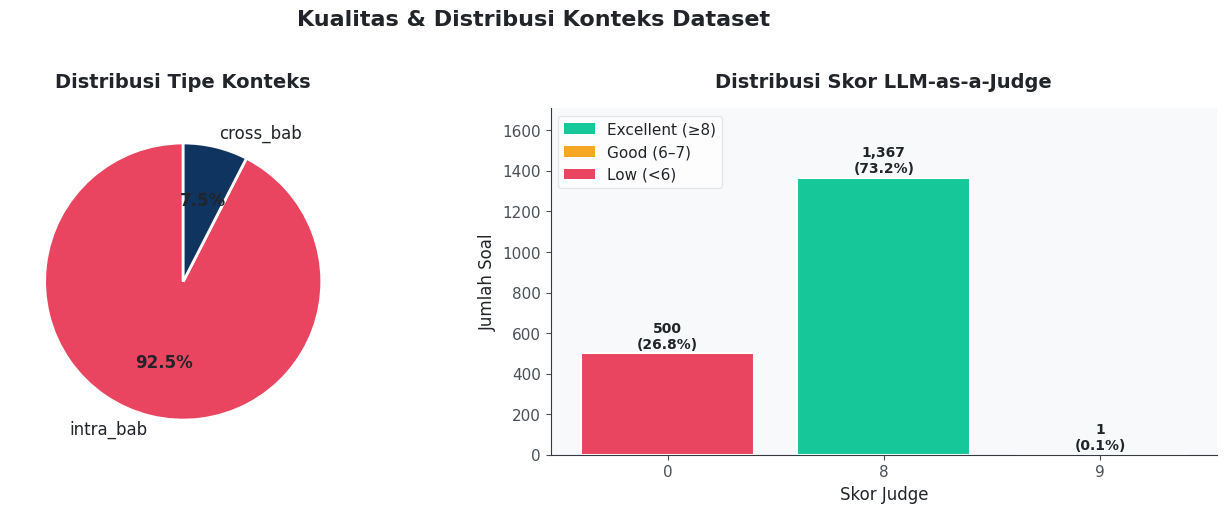

✅ Tersimpan: 02_context_and_score.png


In [6]:
# ── Plot 2: Context Type (Pie) + Judge Score (Bar) — side by side ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Pie: Context Type ---
ctx_counts = Counter(data["context_type"])
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    list(ctx_counts.values()), labels=list(ctx_counts.keys()),
    colors=PALETTE[:len(ctx_counts)], autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 12},
    wedgeprops={"edgecolor": BG_MAIN, "linewidth": 2}
)
for at in autotexts:
    at.set_fontweight("bold")
ax.set_title("Distribusi Tipe Konteks", fontweight="bold", pad=15)

# --- Bar: Judge Score ---
scores = data["judge_score"]
score_ctr = Counter(scores)
all_scores = sorted(score_ctr.keys())
score_colors = ["#16c79a" if s >= 8 else "#f5a623" if s >= 6 else "#e94560" for s in all_scores]
ax = axes[1]
bars = ax.bar([str(s) for s in all_scores],
              [score_ctr[s] for s in all_scores],
              color=score_colors, edgecolor=BG_MAIN, linewidth=1.5)
for bar, s in zip(bars, all_scores):
    val = score_ctr[s]
    pct = val * 100 / len(scores)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Distribusi Skor LLM-as-a-Judge", fontweight="bold", pad=15)
ax.set_xlabel("Skor Judge")
ax.set_ylabel("Jumlah Soal")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
legend_el = [mpatches.Patch(facecolor="#16c79a", label="Excellent (≥8)"),
             mpatches.Patch(facecolor="#f5a623", label="Good (6–7)"),
             mpatches.Patch(facecolor="#e94560", label="Low (<6)")]
ax.legend(handles=legend_el, loc="upper left", framealpha=0.8)
ax.set_ylim(0, max(score_ctr.values()) * 1.25)

fig.suptitle("Kualitas & Distribusi Konteks Dataset", fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "02_context_and_score.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tersimpan: 02_context_and_score.png")


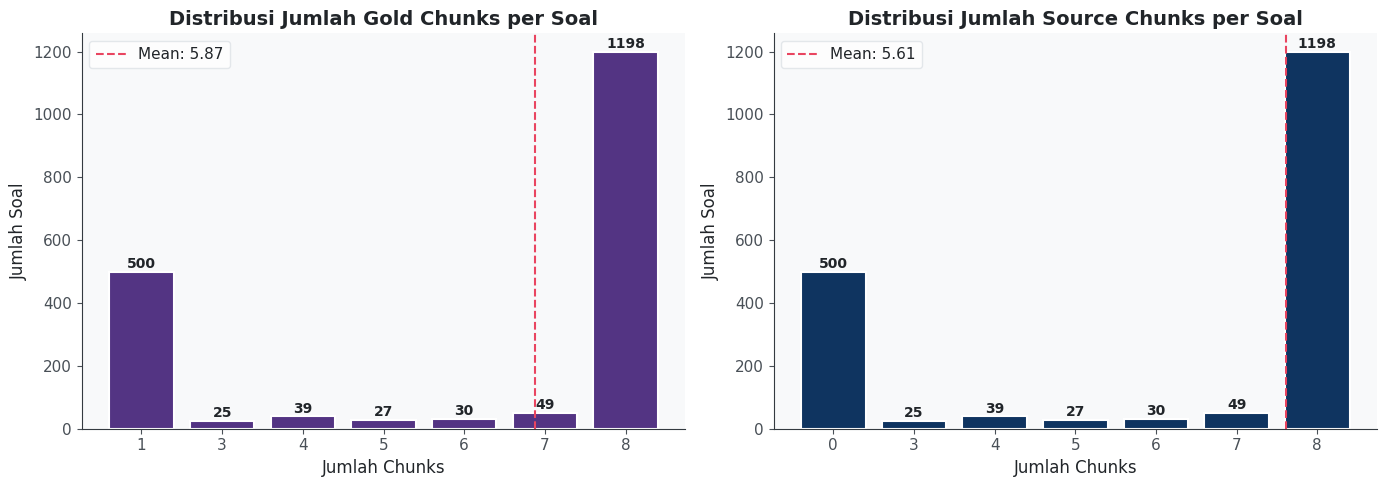

✅ Tersimpan: 03_chunks_distribution.png


In [7]:
# ── Plot 3: Gold Chunks & Source Chunks ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, color, title in [
    (axes[0], "num_gold_chunks",   "#533483", "Distribusi Jumlah Gold Chunks per Soal"),
    (axes[1], "num_source_chunks", "#0f3460", "Distribusi Jumlah Source Chunks per Soal"),
]:
    vals = data[key]
    ctr = Counter(vals)
    sorted_keys = sorted(ctr.keys())
    bar_vals = [ctr[k] for k in sorted_keys]
    bars = ax.bar([str(k) for k in sorted_keys], bar_vals,
                  color=color, edgecolor=BG_MAIN, linewidth=1.5)
    for bar, val in zip(bars, bar_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.axvline(x=np.mean(vals) - min(vals), color="#e94560", linestyle="--",
               label=f"Mean: {np.mean(vals):.2f}", linewidth=1.5)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Jumlah Chunks")
    ax.set_ylabel("Jumlah Soal")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "03_chunks_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tersimpan: 03_chunks_distribution.png")


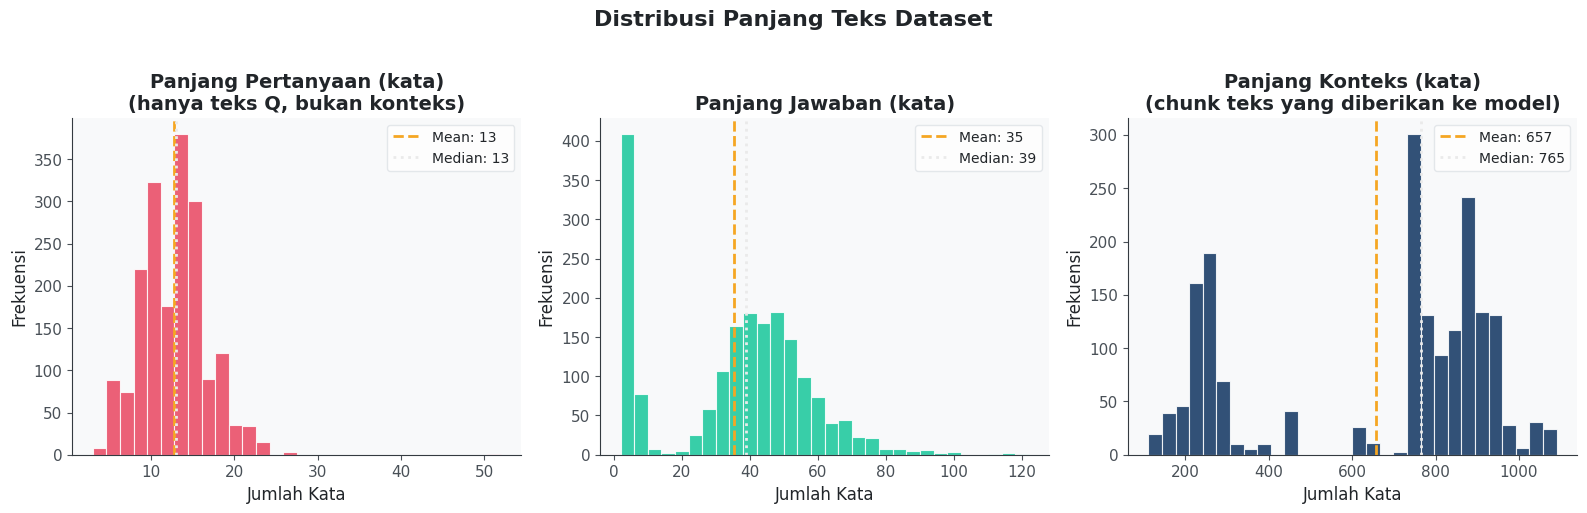

✅ Tersimpan: 04_text_length_distribution.png
   Rata-rata pertanyaan: 12.8 kata


In [8]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
text_fields = [
    ("question_len_word", "#e94560", "Panjang Pertanyaan (kata)\n(hanya teks Q, bukan konteks)"),
    ("answer_len_word",   "#16c79a", "Panjang Jawaban (kata)"),
    ("context_len_word",  "#0f3460", "Panjang Konteks (kata)\n(chunk teks yang diberikan ke model)"),
]

for ax, (key, color, title) in zip(axes, text_fields):
    vals = data[key]
    mean_val = np.mean(vals)
    median_val = np.median(vals)
    ax.hist(vals, bins=30, color=color, edgecolor=BG_MAIN, linewidth=0.8, alpha=0.85)
    ax.axvline(mean_val, color="#f5a623", linestyle="--", linewidth=2,
               label=f"Mean: {mean_val:.0f}")
    ax.axvline(median_val, color="#eaeaea", linestyle=":", linewidth=2,
               label=f"Median: {median_val:.0f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Jumlah Kata")
    ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Distribusi Panjang Teks Dataset", fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "04_text_length_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tersimpan: 04_text_length_distribution.png")
print(f"   Rata-rata pertanyaan: {np.mean(data['question_len_word']):.1f} kata")


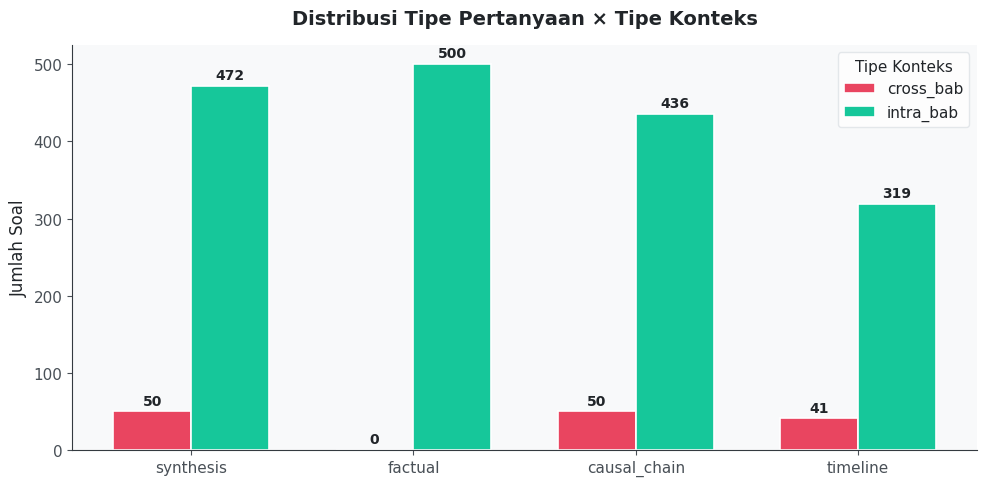

✅ Tersimpan: 05_question_x_context_type.png

📊 Tabel cross-tab:
  Tipe Pertanyaan       cross_bab     intra_bab     Total
  ───────────────────────────────────────────────────────
  synthesis             50            472           522
  factual               0             500           500
  causal_chain          50            436           486
  timeline              41            319           360


In [9]:
# ── Plot 5: Cross-tab Tipe Pertanyaan × Tipe Konteks (BARU) ──────────
from itertools import product

qt_labels = [k for k, _ in Counter(data["question_type"]).most_common()]
ct_labels  = sorted(set(data["context_type"]))

# Hitung cross-tab
cross = defaultdict(lambda: defaultdict(int))
for qt, ct in zip(data["question_type"], data["context_type"]):
    cross[qt][ct] += 1

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(qt_labels))
width = 0.35
ct_colors = [PALETTE[0], PALETTE[3]]

for i, ct in enumerate(ct_labels):
    vals = [cross[qt][ct] for qt in qt_labels]
    offset = (i - len(ct_labels)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=ct,
                  color=ct_colors[i], edgecolor=BG_MAIN, linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(qt_labels)
ax.set_title("Distribusi Tipe Pertanyaan × Tipe Konteks", fontweight="bold", pad=15)
ax.set_ylabel("Jumlah Soal")
ax.legend(title="Tipe Konteks", framealpha=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "05_question_x_context_type.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tersimpan: 05_question_x_context_type.png")

# Tampilkan tabel
print("\n📊 Tabel cross-tab:")
header = f"  {'Tipe Pertanyaan':<20s}" + "".join(f"  {ct:<12s}" for ct in ct_labels) + "  Total"
print(header)
print("  " + "─" * (len(header)-2))
for qt in qt_labels:
    row = f"  {qt:<20s}"
    total = 0
    for ct in ct_labels:
        v = cross[qt][ct]
        row += f"  {v:<12,}"
        total += v
    print(row + f"  {total:,}")


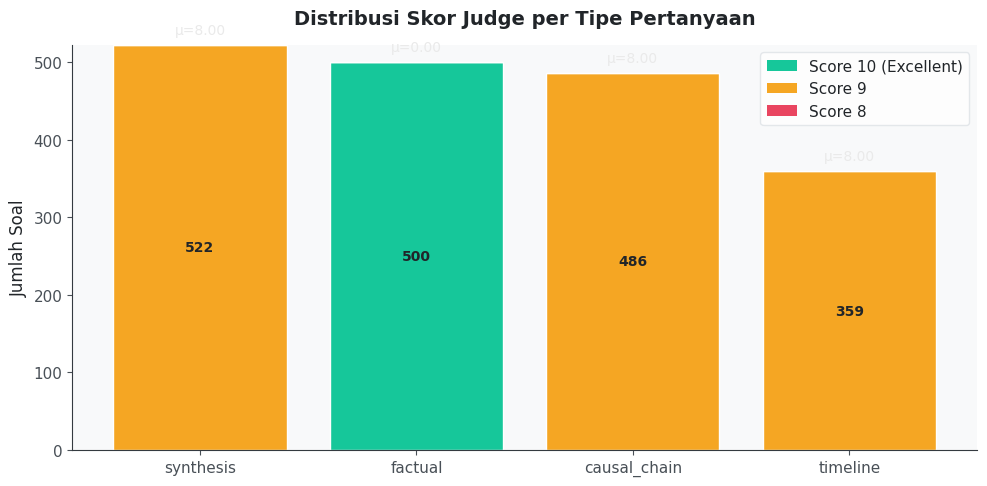

✅ Tersimpan: 06_score_by_question_type.png


In [10]:
# ── Plot 6: Skor Judge per Tipe Pertanyaan (BARU) ────────────────────
score_by_type = defaultdict(list)
for qt, score in zip(data["question_type"], data["judge_score"]):
    score_by_type[qt].append(score)

qt_order = [k for k, _ in Counter(data["question_type"]).most_common()]

fig, ax = plt.subplots(figsize=(10, 5))
positions = np.arange(len(qt_order))

for i, qt in enumerate(qt_order):
    scores_qt = score_by_type[qt]
    mean_s = np.mean(scores_qt)
    # Stacked bar per score value
    score_vals = sorted(set(data["judge_score"]))
    bottom = 0
    s_colors = ["#16c79a", "#f5a623", "#e94560"]
    for j, s_val in enumerate(score_vals):
        cnt = scores_qt.count(s_val)
        bar = ax.bar(i, cnt, bottom=bottom, color=s_colors[j], edgecolor=BG_MAIN, linewidth=1)
        if cnt > 20:
            ax.text(i, bottom + cnt/2, f"{cnt}", ha="center", va="center",
                    fontsize=10, fontweight="bold")
        bottom += cnt
    ax.text(i, bottom + 10, f"μ={mean_s:.2f}", ha="center", va="bottom", fontsize=10, color="#eaeaea")

ax.set_xticks(positions)
ax.set_xticklabels(qt_order)
ax.set_title("Distribusi Skor Judge per Tipe Pertanyaan", fontweight="bold", pad=15)
ax.set_ylabel("Jumlah Soal")
legend_el = [mpatches.Patch(facecolor="#16c79a", label="Score 10 (Excellent)"),
             mpatches.Patch(facecolor="#f5a623", label="Score 9"),
             mpatches.Patch(facecolor="#e94560", label="Score 8")]
ax.legend(handles=legend_el, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "06_score_by_question_type.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tersimpan: 06_score_by_question_type.png")


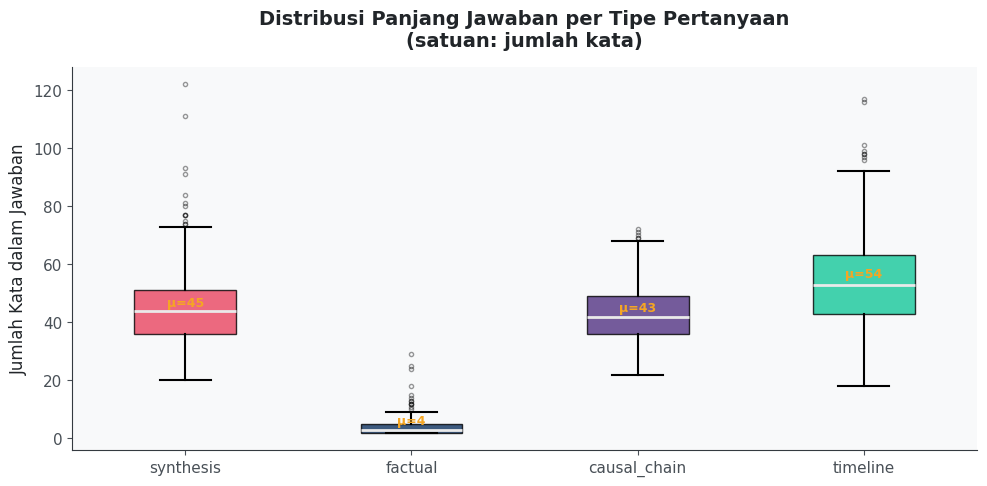

✅ Tersimpan: 07_answer_length_by_type.png

📌 Insight:
  synthesis      : mean=44.7 kata  |  median=44  |  max=122
  factual        : mean=4.0 kata  |  median=3  |  max=29
  causal_chain   : mean=42.9 kata  |  median=42  |  max=72
  timeline       : mean=54.5 kata  |  median=53  |  max=117


In [11]:
# ── Plot 7: Panjang Jawaban per Tipe Pertanyaan (BARU) ────────────────
ans_by_type = defaultdict(list)
for qt, aw in zip(data["question_type"], data["answer_len_word"]):
    ans_by_type[qt].append(aw)

qt_order = [k for k, _ in Counter(data["question_type"]).most_common()]

fig, ax = plt.subplots(figsize=(10, 5))
bp_data = [ans_by_type[qt] for qt in qt_order]
bp = ax.boxplot(bp_data, patch_artist=True, notch=False,
                medianprops={"color": "#eaeaea", "linewidth": 2},
                whiskerprops={"linewidth": 1.5},
                capprops={"linewidth": 1.5},
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
for patch, color in zip(bp["boxes"], PALETTE[:len(qt_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticks(range(1, len(qt_order)+1))
ax.set_xticklabels(qt_order)
ax.set_title("Distribusi Panjang Jawaban per Tipe Pertanyaan\n(satuan: jumlah kata)", fontweight="bold", pad=15)
ax.set_ylabel("Jumlah Kata dalam Jawaban")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tambah mean label
for i, qt in enumerate(qt_order):
    mean_val = np.mean(ans_by_type[qt])
    ax.text(i+1, mean_val, f"μ={mean_val:.0f}", ha="center", va="bottom",
            fontsize=9, color="#f5a623", fontweight="bold")

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "07_answer_length_by_type.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tersimpan: 07_answer_length_by_type.png")
print()
print("📌 Insight:")
for qt in qt_order:
    vals = ans_by_type[qt]
    print(f"  {qt:<15s}: mean={np.mean(vals):.1f} kata  |  median={np.median(vals):.0f}  |  max={max(vals)}")


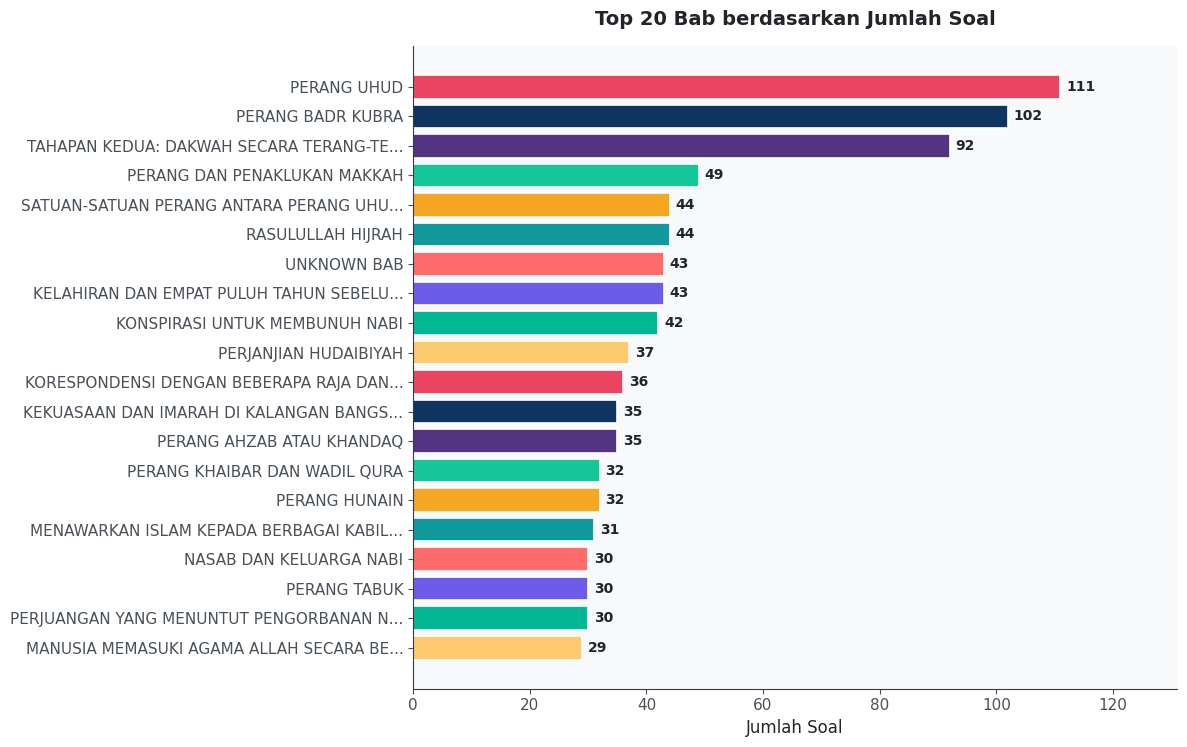

✅ Tersimpan: 08_top_bab.png

   Total unique bab: 57
   UNKNOWN BAB count: 43 soal


In [12]:
# ── Plot 8: Top 20 Bab ───────────────────────────────────────────────
bab_ctr = Counter()
for babs in data["bab_per_qa"]:
    for b in set(babs):
        bab_ctr[b] += 1

top_n = 20
top = bab_ctr.most_common(top_n)
labels_bab = [b[:38]+"..." if len(b) > 38 else b for b, _ in top]
values_bab = [v for _, v in top]

# Tandai UNKNOWN BAB dengan warna berbeda
colors_bab = ["#e94560" if "UNKNOWN" in (b for b, _ in [top[i]])
              else PALETTE[i % len(PALETTE)] for i in range(len(top))]

fig, ax = plt.subplots(figsize=(12, max(7, top_n * 0.38)))
bars = ax.barh(labels_bab, values_bab, color=colors_bab, edgecolor=BG_MAIN, linewidth=1.2)
for bar, val in zip(bars, values_bab):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), ha="left", va="center", fontweight="bold", fontsize=10)
ax.set_title(f"Top {top_n} Bab berdasarkan Jumlah Soal", fontweight="bold", pad=15)
ax.set_xlabel("Jumlah Soal")
ax.set_xlim(0, max(values_bab) * 1.18)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "08_top_bab.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tersimpan: 08_top_bab.png")
print(f"\n   Total unique bab: {len(bab_ctr)}")
print(f"   UNKNOWN BAB count: {bab_ctr.get('UNKNOWN BAB', 0)} soal")


## 4. Inspeksi Sampel QA per Tipe Pertanyaan

In [13]:
# ── Tampilkan 1 contoh QA untuk setiap tipe pertanyaan ───────────────
import textwrap

# Kelompokkan records per tipe
by_type = defaultdict(list)
for r in records:
    by_type[r["metadata"]["type"]].append(r)

for qt in ["factual", "synthesis", "causal_chain", "timeline"]:
    sample = by_type[qt][0]  # ambil record pertama
    msgs = sample["messages"]
    user_content = msgs[1]["content"]
    question = user_content.split("\nPertanyaan: ")[-1].strip() if "\nPertanyaan: " in user_content else ""
    answer = msgs[2]["content"] if len(msgs) > 2 else ""
    meta = sample["metadata"]
    
    print("─" * 65)
    print(f"  🏷️  TIPE: {qt.upper()}")
    print(f"  Bab     : {', '.join(meta.get('bab_titles', []))}")
    print(f"  Score   : {meta.get('judge_score')}  |  Context: {meta.get('context_type')}  |  Chunks: {meta.get('num_source_chunks')}")
    print(f"  Pertanyaan:")
    for line in textwrap.wrap(question, width=60):
        print(f"    {line}")
    print(f"  Jawaban:")
    for line in textwrap.wrap(answer[:300] + ("..." if len(answer)>300 else ""), width=60):
        print(f"    {line}")
    print()


─────────────────────────────────────────────────────────────────
  🏷️  TIPE: FACTUAL
  Bab     : 
  Score   : None  |  Context: intra_bab  |  Chunks: None
  Pertanyaan:
    Ada tiga kabilah yang selalu bersinggungan, tegang, dan
    kacau di Madinah, bahkan sering terjadi perang, siapa saja
    kabilah ini?
  Jawaban:
    Qainuqa', Nadhir, dan Quraizah [1]

─────────────────────────────────────────────────────────────────
  🏷️  TIPE: SYNTHESIS
  Bab     : UNKNOWN BAB
  Score   : 8  |  Context: intra_bab  |  Chunks: 6
  Pertanyaan:
    Apa saja langkah-langkah yang diambil Rasulullah sebelum dan
    selama penaklukan Makkah?
  Jawaban:
    Sebelum penaklukan Makkah, Rasulullah bersiap-siap untuk
    perang dan merahasiakannya. Pasukan Islam bergerak ke arah
    Makkah, singgah di Marr Azh-Zhahran, dan kemudian
    meninggalkan Marr Azh-Zhahran menuju Makkah. Selama
    penaklukan, Rasulullah memasuki Masjidil Haram,
    membersihkannya dari berhala, dan ...

───────────────────────────

## 5. Rekomendasi Strategi Splitting

Berdasarkan temuan EDA di atas, berikut rekomendasi untuk splitting dataset sebelum training/evaluasi.

In [14]:
# ── Analisis komposisi untuk merekomendasikan split strategy ─────────
n = len(records)
qt_dist = Counter(data["question_type"])
ct_dist = Counter(data["context_type"])

print("=" * 65)
print("  📋 REKOMENDASI SPLITTING DATASET")
print("=" * 65)

print(f"""
  Dataset: {n:,} records total
  
  TEMUAN KUNCI:
  ┌─────────────────────────────────────────────────────────┐
  │ 1. Difficulty SERAGAM (semua 'hard')                    │
  │    → Stratifikasi berdasarkan difficulty TIDAK diperlukan│
  │                                                         │
  │ 2. Question type TIDAK SEIMBANG:                        │
  │    factual: {qt_dist['factual']:,} | synthesis: {qt_dist['synthesis']:,} |          │
  │    causal_chain: {qt_dist['causal_chain']:,} | timeline: {qt_dist['timeline']:,}           │
  │    → PERLU stratified split berdasarkan question_type   │
  │                                                         │
  │ 3. Context type sangat miring:                          │
  │    intra_bab: {ct_dist['intra_bab']:,} vs cross_bab: {ct_dist['cross_bab']:,}            │
  │    → Pertimbangkan stratifikasi dobel (type + context)  │
  │                                                         │
  │ 4. UNKNOWN BAB ({bab_ctr.get('UNKNOWN BAB',0)} records):                       │
  │    → Filter dulu sebelum split, atau tandai sebagai     │
  │      subset terpisah untuk analisis                     │
  └─────────────────────────────────────────────────────────┘
  
  REKOMENDASI SPLIT RATIO: 80 / 10 / 10
  ├── Train : {int(n*0.8):,} records
  ├── Val   : {int(n*0.1):,} records
  └── Test  : {int(n*0.1):,} records (≈ {int(n*0.1)} soal untuk benchmark)

  STRATEGI: Stratified split by question_type
  → Menjaga proporsi factual/synthesis/causal_chain/timeline
    tetap konsisten di semua split.
""")

# Simulasi jumlah per split per tipe
print("  SIMULASI JUMLAH PER SPLIT PER TIPE PERTANYAAN:")
print(f"  {'Tipe':<15s}  {'Total':>7s}  {'Train (80%)':>11s}  {'Val (10%)':>9s}  {'Test (10%)':>10s}")
print("  " + "─" * 55)
for qt in ["factual", "synthesis", "causal_chain", "timeline"]:
    tot = qt_dist[qt]
    tr, va, te = int(tot*0.8), int(tot*0.1), int(tot*0.1)
    print(f"  {qt:<15s}  {tot:>7,}  {tr:>11,}  {va:>9,}  {te:>10,}")
print("  " + "─" * 55)
print(f"  {'TOTAL':<15s}  {n:>7,}  {int(n*0.8):>11,}  {int(n*0.1):>9,}  {int(n*0.1):>10,}")
print()
print("  ⚠️  Gunakan random_state=42 untuk reproducibility.")
print("  ⚠️  Lakukan split SETELAH deduplication dan filter UNKNOWN BAB (opsional).")
print("=" * 65)


  📋 REKOMENDASI SPLITTING DATASET

  Dataset: 1,868 records total

  TEMUAN KUNCI:
  ┌─────────────────────────────────────────────────────────┐
  │ 1. Difficulty SERAGAM (semua 'hard')                    │
  │    → Stratifikasi berdasarkan difficulty TIDAK diperlukan│
  │                                                         │
  │ 2. Question type TIDAK SEIMBANG:                        │
  │    factual: 500 | synthesis: 522 |          │
  │    causal_chain: 486 | timeline: 360           │
  │    → PERLU stratified split berdasarkan question_type   │
  │                                                         │
  │ 3. Context type sangat miring:                          │
  │    intra_bab: 1,727 vs cross_bab: 141            │
  │    → Pertimbangkan stratifikasi dobel (type + context)  │
  │                                                         │
  │ 4. UNKNOWN BAB (43 records):                       │
  │    → Filter dulu sebelum split, atau tandai sebagai     │
  │      subset ter

Tidak ada satu pun bab yang bocor ke dua tempat sekaligus.

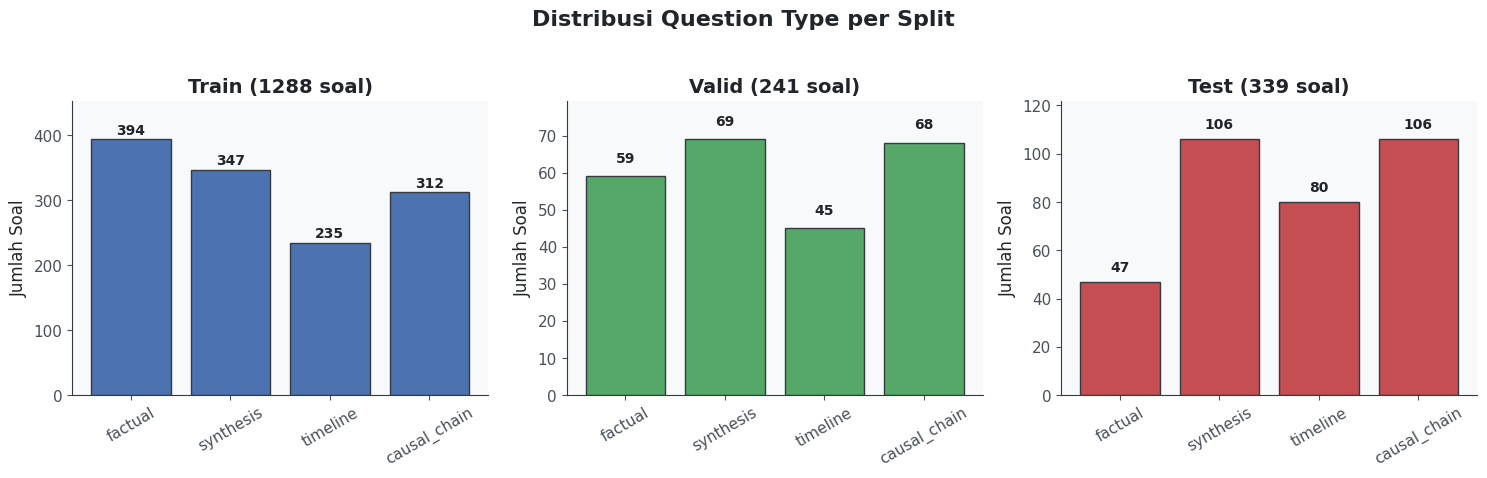

✅ Tersimpan: ../../data/eda_plots\09_distribusi_split_final.png


In [17]:
# ── CELL: VISUALISASI DISTRIBUSI FINAL (DARI FILE OK) ───────────────
import os
import json
import matplotlib.pyplot as plt
from collections import Counter

data_dir = "../../data/finetune_dataset"
plot_dir = "../../data/eda_plots"
splits = ["train_ok.jsonl", "valid_ok.jsonl", "test_ok.jsonl"]
split_names = ["Train", "Valid", "Test"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribusi Question Type per Split", fontweight="bold", fontsize=16)

colors = ["#4c72b0", "#55a868", "#c44e52"]
qt_order = ["factual", "synthesis", "timeline", "causal_chain"]

for ax, fname, sname, color in zip(axes, splits, split_names, colors):
    path = os.path.join(data_dir, fname)
    counts = Counter()
    total = 0
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    r = json.loads(line)
                    qt = r.get("metadata", {}).get("type", "unknown")
                    counts[qt] += 1
                    total += 1
    
    y = [counts.get(qt, 0) for qt in qt_order]
    bars = ax.bar(qt_order, y, color=color, edgecolor="#343a40", linewidth=1)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 3, f"{height}", 
                ha="center", va="bottom", fontsize=10, fontweight="bold")
        
    ax.set_title(f"{sname} ({total} soal)", fontweight="bold")
    ax.set_ylabel("Jumlah Soal")
    ax.set_xticks(range(len(qt_order)))
    ax.set_xticklabels(qt_order, rotation=30)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, max(y + [10]) * 1.15)

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
out_path = os.path.join(plot_dir, "09_distribusi_split_final.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Tersimpan: {out_path}")
